In [1]:
import pandas as pd
import numpy as np

In [2]:
churn_df=pd.read_csv("C:\\Users\\Lakshmy Anil\\Downloads\\customer_churn (1).csv")

In [3]:
churn_df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [4]:
churn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
churn_df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
churn_df.isnull().sum().sum()

0

In [7]:
churn_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
churn_df.SeniorCitizen.value_counts()

0    5901
1    1142
Name: SeniorCitizen, dtype: int64

In [9]:
print(churn_df.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


#Encoding categorical features

In [10]:
from sklearn.preprocessing import LabelEncoder

# Select all columns except 'Churn' and 'customerID'
x_features = churn_df.loc[:, ~churn_df.columns.isin(['Churn', 'customerID'])]
y = churn_df.Churn

# Convert 'TotalCharges' to numeric
x_features['TotalCharges'] = pd.to_numeric(x_features['TotalCharges'], errors='coerce')

# Identify categorical features
categorical_features = x_features.select_dtypes(include=['object']).columns

# Initialize LabelEncoder
le = LabelEncoder()

# Apply Label Encoding to categorical features
for feature in categorical_features:
    x_features[feature] = le.fit_transform(x_features[feature].astype(str))

# Handle missing values
x_features = x_features.fillna(x_features.mean())

# Convert target variable to numeric if it's not already
y = le.fit_transform(y.astype(str))

print(x_features.head())
print("\nTarget variable:")
print(y[:5])  # Print first 5 values of y

   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   
3       1              0        0           0      45             0   
4       0              0        0           0       2             1   

   MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
0              1                0               0             2   
1              0                0               2             0   
2              0                0               2             2   
3              1                0               2             0   
4              0                1               0             0   

   DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract  \
0                 0            0            0                0         0   
1                 

C:\Users\Lakshmy Anil\AppData\Local\Temp\ipykernel_32164\3458191503.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_features['TotalCharges'] = pd.to_numeric(x_features['TotalCharges'], errors='coerce')
C:\Users\Lakshmy Anil\AppData\Local\Temp\ipykernel_32164\3458191503.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_features[feature] = le.fit_transform(x_features[feature].astype(str))
C:\Users\Lakshmy Anil\AppData\Local\Temp\ipykernel_32164\3458191503.py:18: SettingWithCopyWarning: 
A value is 

In [11]:
x_features

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,2,0,2,0,2,2,2,2,1,1,3,84.80,1990.50
7039,0,0,1,1,72,1,2,1,0,2,2,0,2,2,1,1,1,103.20,7362.90
7040,0,0,1,1,11,0,1,0,2,0,0,0,0,0,0,1,2,29.60,346.45
7041,1,1,1,0,4,1,2,1,0,0,0,0,0,0,0,1,3,74.40,306.60


In [12]:
x_features_df=x_features.copy(deep=True)

In [13]:
x_features_df
print(x_features_df.dtypes)

gender                int32
SeniorCitizen         int64
Partner               int32
Dependents            int32
tenure                int64
PhoneService          int32
MultipleLines         int32
InternetService       int32
OnlineSecurity        int32
OnlineBackup          int32
DeviceProtection      int32
TechSupport           int32
StreamingTV           int32
StreamingMovies       int32
Contract              int32
PaperlessBilling      int32
PaymentMethod         int32
MonthlyCharges      float64
TotalCharges        float64
dtype: object


In [14]:
list(x_features.columns)

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges']

In [17]:
list(x_features_df.columns)

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges']

In [15]:
print(x_features.dtypes)

gender                int32
SeniorCitizen         int64
Partner               int32
Dependents            int32
tenure                int64
PhoneService          int32
MultipleLines         int32
InternetService       int32
OnlineSecurity        int32
OnlineBackup          int32
DeviceProtection      int32
TechSupport           int32
StreamingTV           int32
StreamingMovies       int32
Contract              int32
PaperlessBilling      int32
PaymentMethod         int32
MonthlyCharges      float64
TotalCharges        float64
dtype: object


In [16]:
x_features['TotalCharges'] = x_features['TotalCharges'].fillna(0).round().astype(int)
x_features['MonthlyCharges'] = x_features['MonthlyCharges'].fillna(0).round().astype(int)

In [17]:
print(x_features.dtypes)

gender              int32
SeniorCitizen       int64
Partner             int32
Dependents          int32
tenure              int64
PhoneService        int32
MultipleLines       int32
InternetService     int32
OnlineSecurity      int32
OnlineBackup        int32
DeviceProtection    int32
TechSupport         int32
StreamingTV         int32
StreamingMovies     int32
Contract            int32
PaperlessBilling    int32
PaymentMethod       int32
MonthlyCharges      int32
TotalCharges        int32
dtype: object


#Correlation matrix

Correlation Matrix:
                    gender  SeniorCitizen   Partner  Dependents    tenure  \
gender            1.000000      -0.001874 -0.001808    0.010517  0.005106   
SeniorCitizen    -0.001874       1.000000  0.016479   -0.211185  0.016567   
Partner          -0.001808       0.016479  1.000000    0.452676  0.379697   
Dependents        0.010517      -0.211185  0.452676    1.000000  0.159712   
tenure            0.005106       0.016567  0.379697    0.159712  1.000000   
PhoneService     -0.006488       0.008576  0.017706   -0.001762  0.008448   
MultipleLines    -0.006739       0.146185  0.142410   -0.024991  0.343032   
InternetService  -0.000863      -0.032310  0.000891    0.044590 -0.030359   
OnlineSecurity   -0.015017      -0.128221  0.150828    0.152166  0.325468   
OnlineBackup     -0.012057      -0.013632  0.153130    0.091015  0.370876   
DeviceProtection  0.000549      -0.021398  0.166330    0.080537  0.371105   
TechSupport      -0.006825      -0.151268  0.126733    0

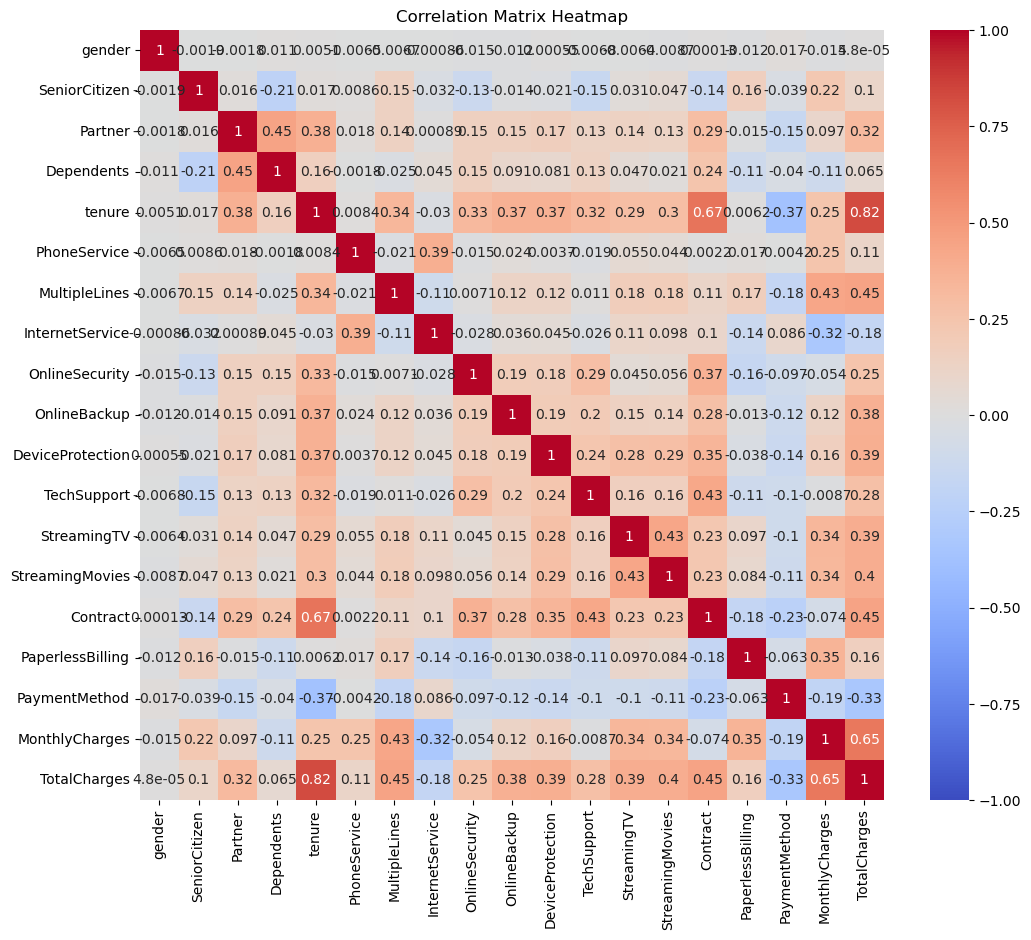

In [18]:
# Calculate the correlation matrix
correlation_matrix = x_features.corr()

# Display the correlation matrix
print("Correlation Matrix:")
print(correlation_matrix)

# If you want to visualize it (optional but recommended for better interpretation)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Correlation Matrix Heatmap')
plt.show()

#Logistic Regression model

In [19]:
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

# Ensure y is numeric if it's not already
y = y.astype(int)

# Add a constant term to the features for the intercept
x = sm.add_constant(x_features)

In [20]:
x.head()

,const,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,1.0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,30,30
1,1.0,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,57,1890
2,1.0,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,54,108
3,1.0,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42,1841
4,1.0,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,71,152


#Train and test sets

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
x_train, x_test, y_train, y_test= train_test_split(x,y,test_size=0.3,random_state=100)

In [23]:
# Fit the model
logit_model = sm.Logit(y_train, x_train)
result = logit_model.fit()

Optimization terminated successfully.
         Current function value: 0.409683
         Iterations 8


#Model summary

In [24]:
print(result.summary())

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 4930
Model:                          Logit   Df Residuals:                     4910
Method:                           MLE   Df Model:                           19
Date:                Tue, 06 Aug 2024   Pseudo R-squ.:                  0.2906
Time:                        21:55:51   Log-Likelihood:                -2019.7
converged:                       True   LL-Null:                       -2847.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -0.5912      0.223     -2.651      0.008      -1.028      -0.154
gender              -0.0407      0.078     -0.522      0.602      -0.194       0.112
SeniorCitizen        0.3125 

#Predicting test data

In [26]:
y_pred = result.predict(x_test)
y_pred_class = (y_pred > 0.5).astype(int)

In [27]:
y_pred.head(15)

4880    0.006191
1541    0.001778
1289    0.011877
5745    0.005980
4873    0.152889
4168    0.029059
1557    0.223528
2892    0.190310
664     0.003122
1588    0.276424
1338    0.190310
6000    0.007379
2310    0.011744
3294    0.643609
290     0.637626
dtype: float64

In [28]:
print("Predicted probabilities:")
print(y_pred[:10])  # Print the first 10 probabilities for inspection

Predicted probabilities:
4880    0.006191
1541    0.001778
1289    0.011877
5745    0.005980
4873    0.152889
4168    0.029059
1557    0.223528
2892    0.190310
664     0.003122
1588    0.276424
dtype: float64


#Create confusion matrix

In [29]:
from sklearn import metrics

In [30]:
conf_matrix= metrics.confusion_matrix(y_test, y_pred_class)
conf_matrix

array([[1363,  184],
       [ 266,  300]], dtype=int64)

#Dataframe with labelled axis

In [31]:
conf_matrix_df= pd.DataFrame(conf_matrix,
                            index=['Actual Negative', 'Actual Positive'],
                            columns=['Predicted Negative', 'Predicted Positive'])
print(conf_matrix_df)

                 Predicted Negative  Predicted Positive
Actual Negative                1363                 184
Actual Positive                 266                 300


#Plot confusion matrix

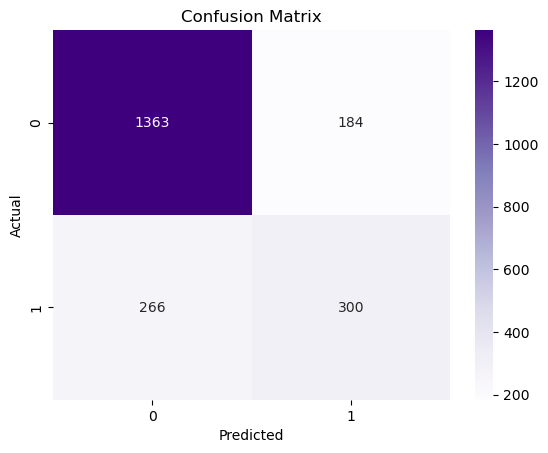

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(conf_matrix,annot=True, fmt='d', cmap='Purples')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#ROC curve AUC

In [33]:
fpr, tpr, thresholds = metrics.roc_curve(y_test,y_pred)
roc_auc= metrics.auc(fpr,tpr)
print(f'AUC:{roc_auc:.2f}')

AUC:0.83


#Classification report

In [34]:
print(metrics.classification_report(y_test,y_pred_class))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1547
           1       0.62      0.53      0.57       566

    accuracy                           0.79      2113
   macro avg       0.73      0.71      0.71      2113
weighted avg       0.78      0.79      0.78      2113



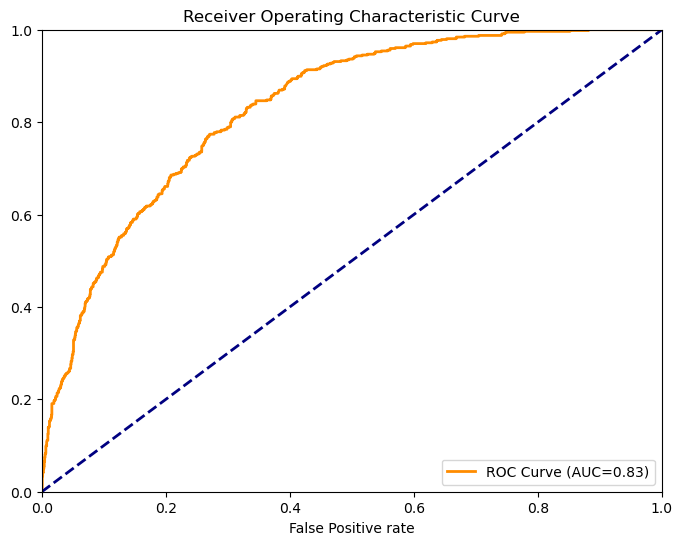

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,color='darkorange',lw=2, label = 'ROC Curve (AUC=%0.2f)'% roc_auc)
plt.plot([0,1],[0,1], color= 'navy', lw=2, linestyle='--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.0])
plt.xlabel('False Positive rate')
plt.title('Receiver Operating Characteristic Curve')
plt.legend(loc="lower right")
plt.show()

#Splitting dataset after dropping more columns

In [36]:
# Drop TotalCharges and low-impact features
features_to_drop = ['TotalCharges', 'gender', 'Partner', 'Dependents']
x_features_revised = x_features_df.drop(columns=features_to_drop)

# Create interaction term
x_features_revised['Tenure_Contract'] = x_features_revised['tenure'] * x_features_revised['Contract']

# Create AvgMonthlyCharge
x_features_revised['AvgMonthlyCharge'] = x_features_df['TotalCharges'] / (x_features_df['tenure'] + 1)  # Adding 1 to avoid division by zero

# Add squared terms for continuous variables
x_features_revised['tenure_squared'] = x_features_revised['tenure'] ** 2
x_features_revised['MonthlyCharges_squared'] = x_features_revised['MonthlyCharges'] ** 2

# One-hot encode categorical variables
categorical_features = ['InternetService', 'Contract', 'PaymentMethod']
x_features_encoded = pd.get_dummies(x_features_revised, columns=categorical_features, drop_first=True)

# Split the data
x_train, x_test, y_train, y_test = train_test_split(x_features_encoded, y, test_size=0.3, random_state=100)

# Add constant term to train and test data
x_train_const = sm.add_constant(x_train)
x_test_const = sm.add_constant(x_test)

# Build the model
logit_model_revised = sm.Logit(y_train, x_train_const)
result_revised = logit_model_revised.fit()

# Print model summary
print(result_revised.summary())

Optimization terminated successfully.
         Current function value: 0.401161
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 4930
Model:                          Logit   Df Residuals:                     4906
Method:                           MLE   Df Model:                           23
Date:                Tue, 06 Aug 2024   Pseudo R-squ.:                  0.3054
Time:                        21:57:53   Log-Likelihood:                -1977.7
converged:                       True   LL-Null:                       -2847.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      1.5837      1.008      1.571      0.116      -0.392      

#Predicting on new dataset

In [37]:
y_pred_2 = result_revised.predict(x_test_const)
y_pred_class_2 = (y_pred > 0.5).astype(int)

In [38]:
y_pred_class.head(15)

4880    0
1541    0
1289    0
5745    0
4873    0
4168    0
1557    0
2892    0
664     0
1588    0
1338    0
6000    0
2310    0
3294    1
290     1
dtype: int32

In [39]:
print("Predicted probabilities:")
print(y_pred_2[:10])  # Print the first 10 probabilities for inspection

Predicted probabilities:
4880    0.007070
1541    0.008909
1289    0.028749
5745    0.015184
4873    0.124746
4168    0.021378
1557    0.187031
2892    0.180319
664     0.008540
1588    0.274967
dtype: float64


#New confusion matrix

In [40]:
conf_matrix= metrics.confusion_matrix(y_test, y_pred_class_2)
conf_matrix

array([[1363,  184],
       [ 266,  300]], dtype=int64)

In [41]:
conf_matrix_df= pd.DataFrame(conf_matrix,
                            index=['Actual Negative', 'Actual Positive'],
                            columns=['Predicted Negative', 'Predicted Positive'])
print(conf_matrix_df)

                 Predicted Negative  Predicted Positive
Actual Negative                1363                 184
Actual Positive                 266                 300


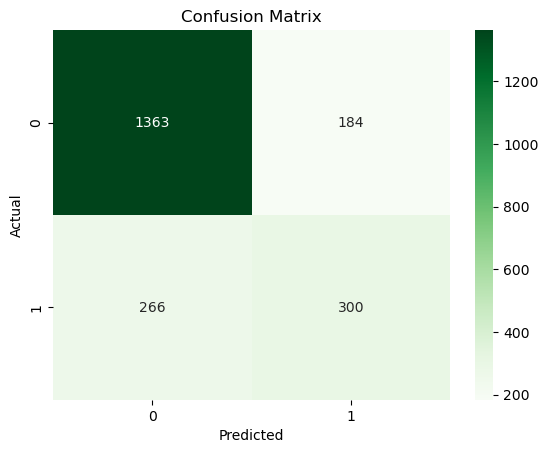

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(conf_matrix,annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [44]:
fpr, tpr, thresholds = metrics.roc_curve(y_test,y_pred_2)
roc_auc= metrics.auc(fpr,tpr)
print(f'AUC:{roc_auc:.2f}')

AUC:0.84


In [45]:
print(metrics.classification_report(y_test,y_pred_class_2))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1547
           1       0.62      0.53      0.57       566

    accuracy                           0.79      2113
   macro avg       0.73      0.71      0.71      2113
weighted avg       0.78      0.79      0.78      2113



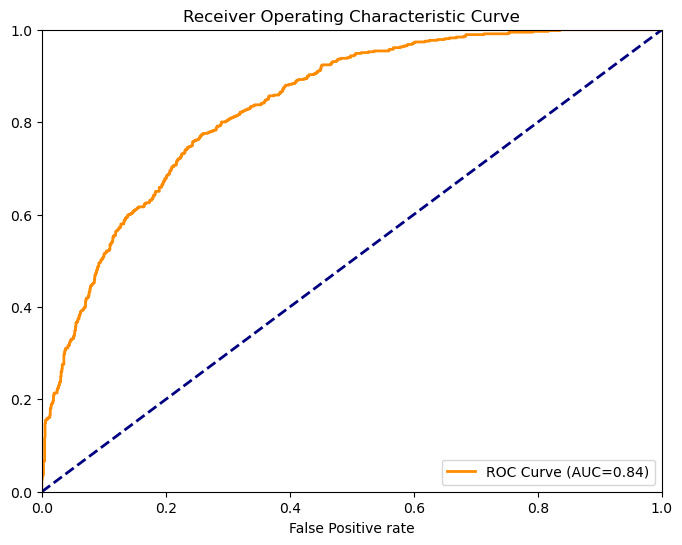

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,color='darkorange',lw=2, label = 'ROC Curve (AUC=%0.2f)'% roc_auc)
plt.plot([0,1],[0,1], color= 'navy', lw=2, linestyle='--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.0])
plt.xlabel('False Positive rate')
plt.title('Receiver Operating Characteristic Curve')
plt.legend(loc="lower right")
plt.show()